# TF-IDF + Logistic Regression

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

### Загрузка данных

In [15]:
df = pd.read_csv("../data/ru-hard-detection-clean.csv")

df["label"] = df["source"].map({
    "human": 0,
    "ai": 1
})
df['stratify_col'] = df['label'].astype(str) + "_" + df['dataset'].astype(str)
df['group_id'] = df['dataset'] + "_" + df['id'].astype(str)
df.iloc[478:482]

,id,text,model,source,dataset,label,stratify_col,group_id
478,479,"родине. Кассиль не идеализирует своих героев, ...",deepseek-chat,ai,Corus Essays,1,1_Corus Essays,Corus Essays_479
479,480,"предубеждениями, доказывая, что в борьбе за Ро...",gemini-2.0-flash,ai,Corus Essays,1,1_Corus Essays,Corus Essays_480
480,1,Период с 1922 по 1939 год — время становления ...,NaN,human,Corus Essays,0,0_Corus Essays,Corus Essays_1
481,2,"Время, в которое развернулась деятельность зна...",NaN,human,Corus Essays,0,0_Corus Essays,Corus Essays_2


### Предобработка текста

In [16]:
import pymorphy3
import nltk
from nltk.tokenize import word_tokenize
# nltk.download("punkt")
morph = pymorphy3.MorphAnalyzer()


def clean_text(text: str):
    text = text.lower()
    tokens = word_tokenize(text)    
    clean_tokens = []
    for word in tokens:
        if word in '.,!?':
            clean_tokens.append(word)
        else:
            clean_tokens.append(morph.parse(word)[0].normal_form)
            
    return " ".join(clean_tokens)

In [17]:
df['cleaned_text'] = df['text'].apply(clean_text)

### Train / test split

In [18]:
from sklearn.model_selection import train_test_split, GroupShuffleSplit

In [19]:
# X_train, X_test, y_train, y_test = train_test_split(
#     df["cleaned_text"],
#     df["label"],
#     test_size=0.2,
#     random_state=42,
#     stratify=df["stratify_col"]
# )

In [20]:
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

train_idx, test_idx = next(gss.split(df["cleaned_text"], df["label"], groups=df["group_id"]))

X_train = df["cleaned_text"].iloc[train_idx]
X_test = df["cleaned_text"].iloc[test_idx]
y_train = df["label"].iloc[train_idx]
y_test = df["label"].iloc[test_idx]

### Сборка модели

#### Настройка пайплайна

In [21]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

In [22]:
model = Pipeline([
    ("tfidf", TfidfVectorizer(        
        ngram_range=(1,3)
    )),
    ("clf", LogisticRegression(
        solver='liblinear',
        max_iter=1000,
        # n_jobs=-1,
        random_state=42
    ))
])

#### Настраиваем сетку параметров

In [23]:
from sklearn.model_selection import GridSearchCV

In [24]:
param_grid = {
    'tfidf__max_features': [10000, 30000, 50000],
    'clf__C': [0.1, 1, 10, 100],
    'clf__penalty': ['l1', 'l2']
}

In [25]:
grid_search = GridSearchCV(model, param_grid, cv=5, scoring='f1', n_jobs=-1, verbose=1)
grid_search.fit(X_train, y_train)
print(f"Лучшие параметры: {grid_search.best_params_}")
print(f"Лучший результат F1: {grid_search.best_score_:.4f}")

best_model = grid_search.best_estimator_

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Лучшие параметры: {'clf__C': 100, 'clf__penalty': 'l2', 'tfidf__max_features': 30000}
Лучший результат F1: 0.9498


c:\Users\danil\PycharmProjects\AiTextDetector\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


### Метрики

In [26]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, confusion_matrix, roc_curve, auc, ConfusionMatrixDisplay)

y_pred = best_model.predict(X_test)

metrics = {
    'Accuracy': accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred),
    'Recall': recall_score(y_test, y_pred),
    'F1': f1_score(y_test, y_pred),
    'model_obj': model # сохраняем для ROC-кривых
}
metrics

{'Accuracy': 0.9826388888888888,
 'Precision': 0.9727891156462585,
 'Recall': 0.9930555555555556,
 'F1': 0.9828178694158075,
 'model_obj': Pipeline(steps=[('tfidf', TfidfVectorizer(ngram_range=(1, 3))),
                 ('clf',
                  LogisticRegression(max_iter=1000, random_state=42,
                                     solver='liblinear'))])}

### Матрица ошибок

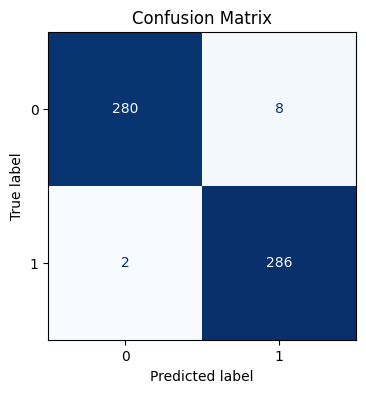

In [27]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

fig, ax = plt.subplots(figsize=(4, 4))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
plt.title("Confusion Matrix")
plt.show()

### Построение ROC-кривой

C:\Users\danil\AppData\Local\Temp\ipykernel_14932\689594043.py:11: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "k--" (-> linestyle='--'). The keyword argument will take precedence.
  plt.plot([0, 1], [0, 1], 'k--', color='navy', lw=2, linestyle='--')
C:\Users\danil\AppData\Local\Temp\ipykernel_14932\689594043.py:11: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  plt.plot([0, 1], [0, 1], 'k--', color='navy', lw=2, linestyle='--')


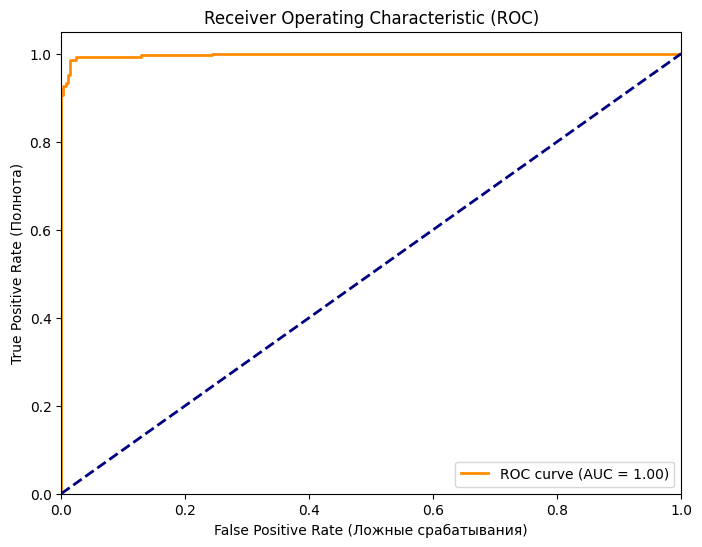

In [29]:
if hasattr(best_model, "predict_proba"):
    y_score = best_model.predict_proba(X_test)[:, 1]
else:
    y_score = best_model.decision_function(X_test)
    
fpr, tpr, _ = roc_curve(y_test, y_score)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--', color='navy', lw=2, linestyle='--')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (Ложные срабатывания)')
plt.ylabel('True Positive Rate (Полнота)')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.show()

### Сохраняем лучшую модель для дальнейшего инференса

In [33]:
import joblib

joblib.dump(best_model, '../models/ai_detector_model.pkl')

['../models/ai_detector_model.pkl']